# Numerical Simulation Laboratory - Notebook 8

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

## Exercise 08.1
By using the ansatz $$\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+e^{-\frac{(x+\mu)^2}{2\sigma^2}} $$ for the wave function one can analytically compute
$$\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}=\frac{1}{2\sigma^2}\left\{1-\frac{1}{\sigma^2}\left[x^2+\mu^2-2x\mu\tanh\left(\frac{x\mu}{\sigma^2}\right) \right] \right\}+x^4-\frac{5}{2}x^2\text{,}$$
with $\hbar=1$ and $m=1$.

The expectation value of the ground state energy can be found with a Variational Monte Carlo method by using the metropolis algorithm to sample the square modulus of the trial wave function. This means that the acceptance probability is $$A(x|y)=\min\left[1,\frac{|\Psi_T^{\sigma,\mu}(x)|^2}{|\Psi_T^{\sigma,\mu}(y)|^2}\right]\text{.}$$

The starting values $\mu=0.85$ and $\sigma=0.6$ were chosen by looking at the plot of the ground state wave function obtained by matrix diagonalization. With these starting values the variational algorithm converges to $\langle\hat{H}\rangle_T=-0.435\pm0.003$, which shows that the algorithm is working, since the true ground state energy is $E_\text{GS}\approx-0.46047$ and the values of $\mu$ and $\sigma$ aren't optimized. 

The step size of the Metropolis algorithm was chosen by having an acceptance rate of about $50\%$. The below graph shows how the algorithm with these initial conditions converges to a value of ground state energy, which is different from the one found with matrix diagonalization.

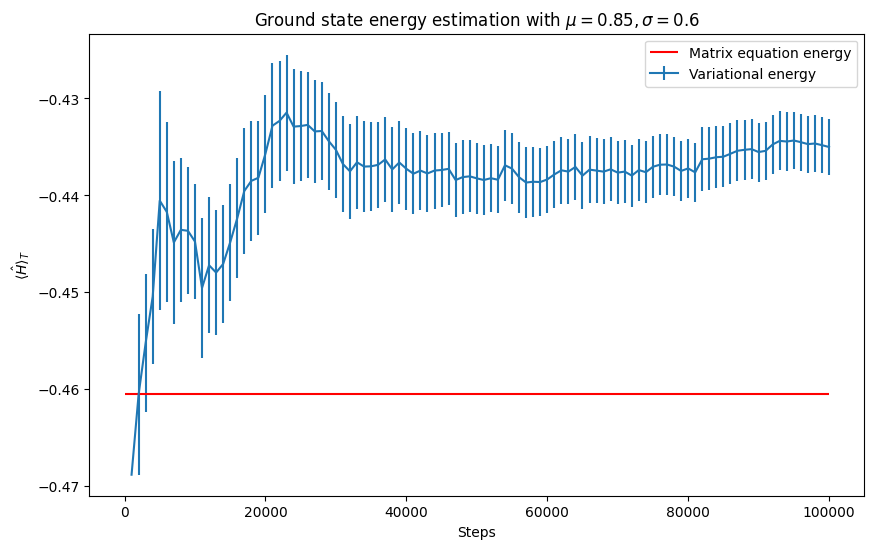

In [4]:
blocks, energy, err = np.loadtxt("../08-Exercises/OUTPUT/output_1.out", unpack=True)

E_gs = -0.460465879692715

fig = plt.figure(figsize=(10,6))
plt.errorbar(blocks*1000, energy, err, label="Variational energy")
plt.hlines(E_gs, 0, blocks[-1]*1000, color="red", label="Matrix equation energy")
plt.title("Ground state energy estimation with $\\mu=0.85,\\sigma=0.6$")
plt.xlabel("Steps")
plt.ylabel(r"$\langle\hat{H}\rangle_T$")
plt.legend();

In [ ]:
## Exercise 08.2